# Mini-Project: Predicting Heart Disease Using Logistic Regression

Week 9, Day 3

Goal: predict whether a patient has heart disease from medical attributes (Heart Disease UCI dataset), with a logistic regression model evaluated by accuracy, precision, recall, F1 score and a confusion matrix.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

RANDOM_STATE = 42
sns.set_style('whitegrid')

## 1. Data Preparation

### Load the dataset

In [2]:
# Local copy in the repo; otherwise read the zip provided by the bootcamp
csv_path = "data/heart_disease_uci.csv"
if not os.path.exists(csv_path):
    csv_path = ("https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/"
                "Week%205/Day%205%20-%20Mini%20Project/UCI%20Heart%20Disease%20Data.zip")

df = pd.read_csv(csv_path)
print(df.shape)
display(df.head())

(920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**Columns:** `age`, `sex`, `dataset` (hospital of origin), `cp` (chest pain type), `trestbps` (resting blood pressure), `chol` (serum cholesterol), `fbs` (fasting blood sugar > 120 mg/dl), `restecg` (resting ECG), `thalch` (max heart rate), `exang` (exercise-induced angina), `oldpeak` (ST depression), `slope` (slope of the ST segment), `ca` (number of major vessels coloured by fluoroscopy), `thal` (thalassemia), `num` (diagnosis: 0 = no disease, 1–4 = increasing severity).

### Exploratory Data Analysis

In [3]:
df.info()
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
display(pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('missing', ascending=False))

# Physiologically impossible zeros are actually missing measurements
print("chol == 0:", (df['chol'] == 0).sum(), "| trestbps == 0:", (df['trestbps'] == 0).sum())

,missing,%
ca,611,66.4
thal,486,52.8
slope,309,33.6
fbs,90,9.8
oldpeak,62,6.7
trestbps,59,6.4
exang,55,6.0
thalch,55,6.0
chol,30,3.3
restecg,2,0.2


chol == 0: 172 | trestbps == 0: 1


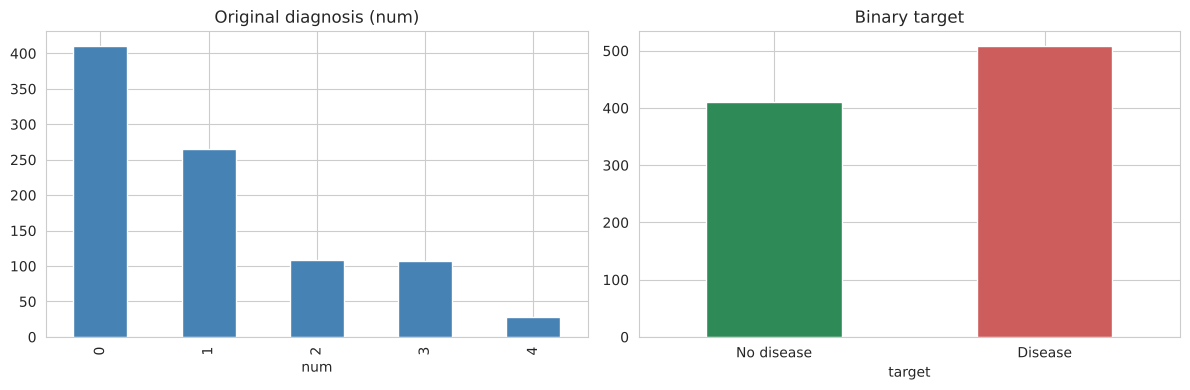

target
1    0.553
0    0.447
Name: proportion, dtype: float64


In [5]:
# Target: num = 0 -> no disease, num 1-4 -> disease
df['target'] = (df['num'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['num'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Original diagnosis (num)')
axes[0].set_xlabel('num')
df['target'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['seagreen', 'indianred'])
axes[1].set_xticklabels(['No disease', 'Disease'], rotation=0)
axes[1].set_title('Binary target')
plt.tight_layout()
plt.show()

print(df['target'].value_counts(normalize=True).round(3))

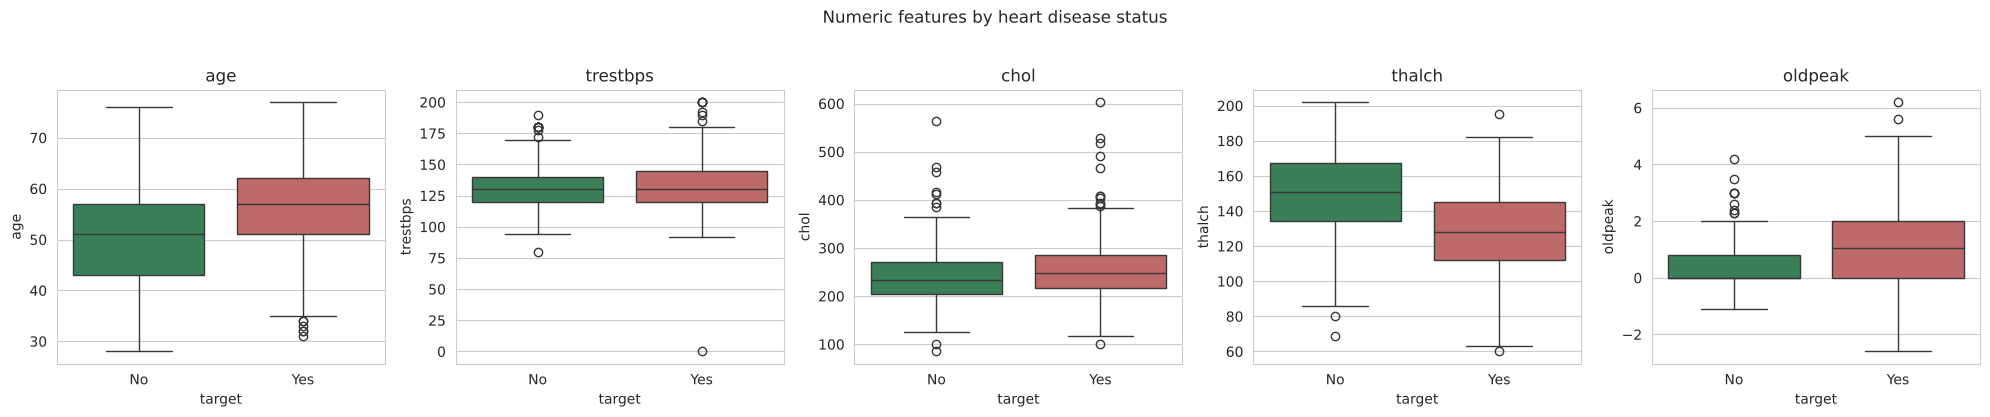

In [6]:
num_cols_eda = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, num_cols_eda):
    data = df[df['chol'] > 0] if col == 'chol' else df
    sns.boxplot(x='target', y=col, data=data, ax=ax, hue='target', palette=['seagreen', 'indianred'], legend=False)
    ax.set_xticks([0, 1], ['No', 'Yes'])
    ax.set_title(col)
plt.suptitle('Numeric features by heart disease status', y=1.03)
plt.tight_layout()
plt.show()

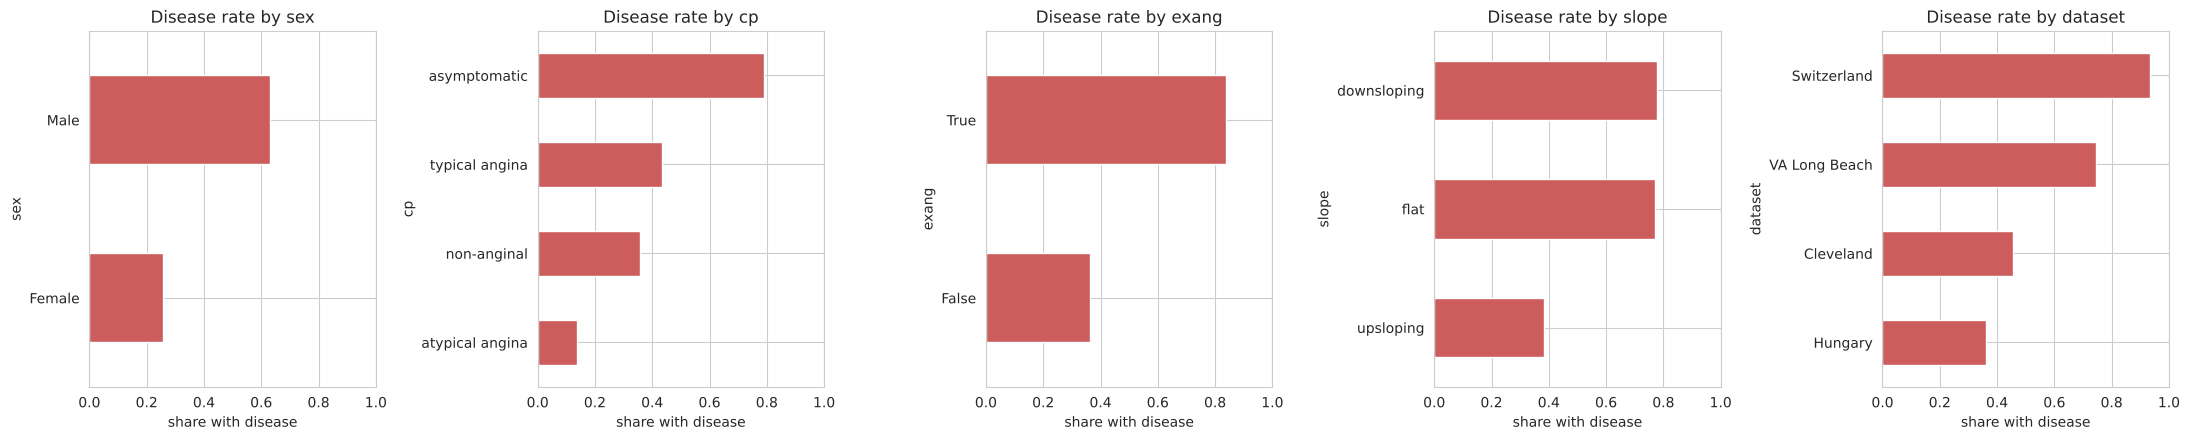

In [7]:
cat_cols_eda = ['sex', 'cp', 'exang', 'slope', 'dataset']
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, col in zip(axes, cat_cols_eda):
    rate = df.groupby(col)['target'].mean().sort_values()
    rate.plot(kind='barh', ax=ax, color='indianred')
    ax.set_xlim(0, 1)
    ax.set_title(f'Disease rate by {col}')
    ax.set_xlabel('share with disease')
plt.tight_layout()
plt.show()

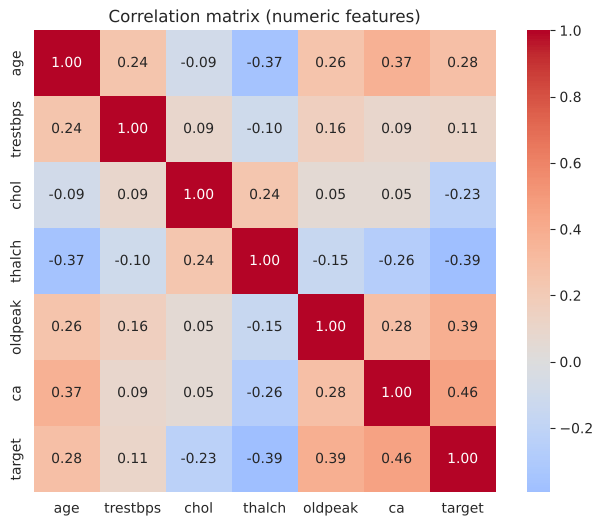

In [8]:
plt.figure(figsize=(8, 6))
corr = df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix (numeric features)')
plt.show()

**EDA findings:**
- 920 patients from 4 hospitals; the classes are fairly balanced (~55% with disease), so accuracy is meaningful but we also look at precision/recall.
- Strong signals: patients with disease are **older**, reach a **lower max heart rate** (`thalch`), have a **higher ST depression** (`oldpeak`), more often have **exercise-induced angina** and **asymptomatic chest pain** (`cp`). Men have a much higher disease rate than women (63% vs 26%).
- Missing values: `ca` (66%) and `thal` (53%) are mostly missing (only well recorded in Cleveland), `slope` is 34% missing, and a few numeric columns are 6–7% missing. 172 patients have `chol = 0`, which is impossible and means "not measured".
- The disease rate varies hugely by hospital (`dataset`), from 36% in Hungary to 93% in Switzerland: this reflects how patients were recruited, not a medical cause.

### Preprocessing

In [9]:
data = df.copy()

# Impossible zeros -> missing
data.loc[data['chol'] == 0, 'chol'] = np.nan
data.loc[data['trestbps'] == 0, 'trestbps'] = np.nan

# Booleans stored as objects -> strings so they are one-hot encoded like other categories
for col in ['fbs', 'exang']:
    data[col] = data[col].map({True: 'yes', False: 'no', 'TRUE': 'yes', 'FALSE': 'no'})

# Drop: id (identifier), num (original target), dataset (hospital = recruitment bias, not a medical feature),
# ca and thal (more than half missing -> imputing them would mostly invent data)
X = data.drop(columns=['id', 'num', 'target', 'dataset', 'ca', 'thal'])
y = data['target']

num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
print("Numeric:", num_cols)
print("Categorical:", cat_cols)

preprocess = ColumnTransformer([
    # numeric: median imputation (robust to outliers) + scaling
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), num_cols),
    # categorical: missing values become their own category, then one-hot encoding
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), cat_cols),
])

Numeric: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']


All imputation and scaling steps are inside a `Pipeline`, so they are **fitted on the training set only** and then applied to the test set, which avoids data leakage.

## 2. Model Training

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

model = Pipeline([
    ('pre', preprocess),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
model.fit(X_train, y_train)

Train: (736, 11) | Test: (184, 11)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['age','sex','cp',...,'exang','oldpeak','slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not spec

In [11]:
# 5-fold cross-validation on the training set to check the score is stable
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
print("CV accuracy per fold:", cv_scores.round(3))
print(f"Mean CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV accuracy per fold: [0.797 0.776 0.878 0.782 0.81 ]
Mean CV accuracy: 0.808 ± 0.037


## 3. Model Evaluation

In [12]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['No disease', 'Disease']))

Accuracy : 0.8424
Precision: 0.8411
Recall   : 0.8824
F1 score : 0.8612
ROC AUC  : 0.9076

Classification report:
              precision    recall  f1-score   support

  No disease       0.84      0.79      0.82        82
     Disease       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



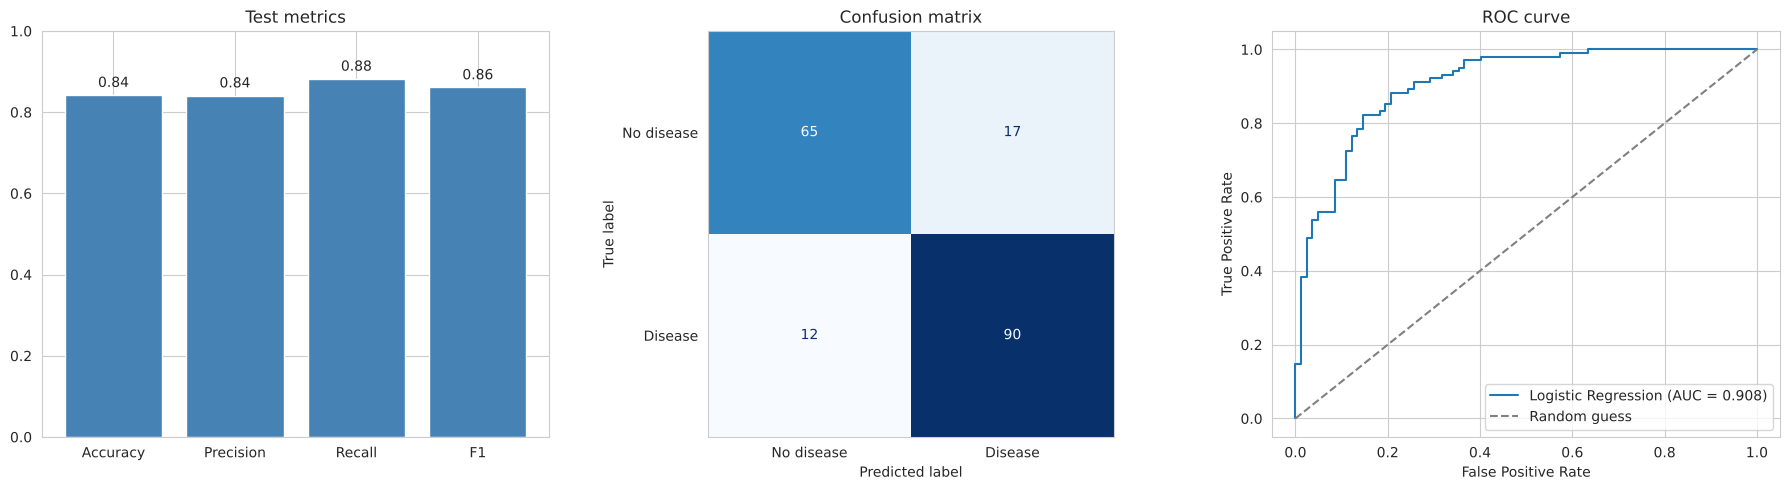

True negatives: 65 | False positives: 17 | False negatives: 12 | True positives: 90


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Metrics
axes[0].bar(['Accuracy', 'Precision', 'Recall', 'F1'], [acc, prec, rec, f1], color='steelblue')
axes[0].set_ylim(0, 1)
axes[0].set_title('Test metrics')
for i, v in enumerate([acc, prec, rec, f1]):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No disease', 'Disease']).plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion matrix')
axes[1].grid(False)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC curve')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives: {tn} | False positives: {fp} | False negatives: {fn} | True positives: {tp}")

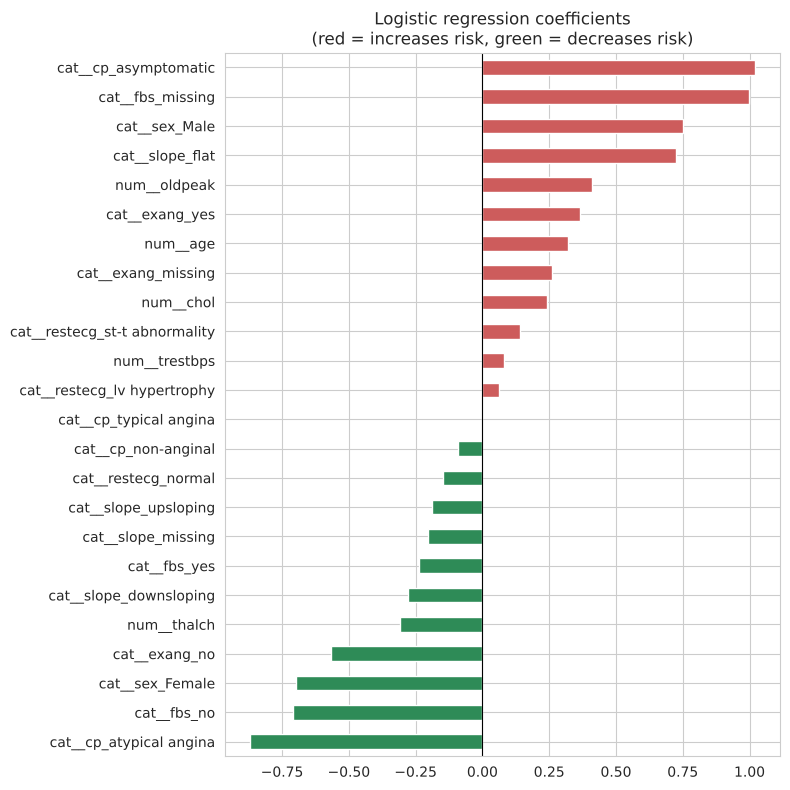

In [14]:
# Which features drive the prediction? (coefficients on scaled / one-hot features)
feature_names = model.named_steps['pre'].get_feature_names_out()
coefs = pd.Series(model.named_steps['lr'].coef_[0], index=feature_names).sort_values()

plt.figure(figsize=(8, 8))
coefs.plot(kind='barh', color=['seagreen' if c < 0 else 'indianred' for c in coefs])
plt.title('Logistic regression coefficients\n(red = increases risk, green = decreases risk)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Conclusion

- The logistic regression predicts heart disease with good performance on the test set: **accuracy 0.84, precision 0.84, recall 0.88, F1 0.86, ROC AUC 0.91**. The 5-fold cross-validation accuracy (0.81 ± 0.04) is close to the test score, so the result is not a lucky split.
- **Recall** is the most important metric in this medical context: a false negative is a sick patient sent home. The model catches 90 of the 102 sick patients in the test set (12 false negatives), and raises 17 false alarms among the 82 healthy ones. If needed, lowering the decision threshold below 0.5 would increase recall at the cost of more false positives (extra tests for healthy patients).
- The coefficients are medically consistent: **asymptomatic chest pain, being male, exercise-induced angina, high ST depression (`oldpeak`) and a flat ST slope** increase the risk, while a **high max heart rate** (`thalch`) and atypical/non-anginal chest pain decrease it.
- `fbs_missing` also gets a large positive weight: the fasting blood sugar is mostly missing in the Swiss data, where almost every patient is sick, so the model partly learns *where* the patient comes from. This is a reminder that missing values are not random here.
- Limitations: the data comes from 4 hospitals with different recruitment and many missing values (`ca` and `thal` were dropped). Adding these features for hospitals that recorded them, or collecting more complete data, could improve the model.